## Import Libraries

In [287]:
import numpy as np
import mne
import re
import os
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, balanced_accuracy_score 
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [290]:
FS = 256                 # CHB-MIT sampling frequency
SEGMENT_SEC = 2          # 2-second segments
SEGMENT_SAMPLES = FS * SEGMENT_SEC

In [293]:
path = r"C:\Users\Admin\PycharmProjects\SVM-RF-with-Sleep-Database"
data_dir = os.path.join(path, "Chb01")
files = os.listdir(data_dir)
print("Files in folder:", files)

# Assign the first and second items
edf_file = files[1]
summary_file = files[0]


edf_path = os.path.join(data_dir, edf_file)
summary_path = os.path.join(data_dir, summary_file)

print("First file:", edf_file)
print("Summary file:", summary_file)
print(summary_path)
print(edf_path)

Files in folder: ['chb01-summary.txt', 'chb01_03.edf']
First file: chb01_03.edf
Summary file: chb01-summary.txt
C:\Users\Admin\PycharmProjects\SVM-RF-with-Sleep-Database\Chb01\chb01-summary.txt
C:\Users\Admin\PycharmProjects\SVM-RF-with-Sleep-Database\Chb01\chb01_03.edf


## Load EEG from EDF File

In [296]:
def load_chbmit_eeg(edf_path):
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    #raw.pick_types(eeg=True)
    raw.pick("eeg")
    data = raw.get_data()               # (channels, samples)
    duration_sec = raw.times[-1]
    return data, FS, duration_sec

## Parse the Summary File

In [299]:
def parse_chbmit_summary(summary_path, edf_file):
    seizure_intervals = []

    with open(summary_path, "r") as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        if edf_file in lines[i]:

            # Extract number of seizures
            num_match = re.search(r"\d+", lines[i+3])
            if not num_match:
                return []

            num_seizures = int(num_match.group())

            j = i + 4  # Start reading seizure times after count line

            for _ in range(num_seizures):

                start_match = re.search(r"\d+", lines[j])
                end_match   = re.search(r"\d+", lines[j+1])

                if start_match and end_match:
                    start = int(start_match.group())
                    end   = int(end_match.group())
                    seizure_intervals.append((start, end))

                j += 2

            break

        i += 1

    return seizure_intervals

## Create Sample-Level Binary Labels

In [302]:
def create_sample_labels(duration_sec, fs, seizure_intervals):
    total_samples = int(duration_sec * fs)
    labels = np.zeros(total_samples, dtype=int)

    for start, end in seizure_intervals:
        labels[int(start*fs):int(end*fs)] = 1

    return labels

## Segment EEG + Labels (2 seconds)

In [305]:
def segment_eeg(data, fs, window_sec=5):
    samples_per_segment = int(window_sec * fs)
    total_samples = data.shape[1]

    segments = []
    segment_times = []

    for start_sample in range(0, total_samples, samples_per_segment):
        end_sample = start_sample + samples_per_segment
        if end_sample > total_samples:
            break

        segments.append(data[:, start_sample:end_sample])

        # Convert to seconds
        start_sec = start_sample / fs
        end_sec = end_sample / fs
        segment_times.append((start_sec, end_sec))

    return np.array(segments), segment_times

In [308]:
data, fs, duration = load_chbmit_eeg(edf_path)

C:\Users\Admin\AppData\Local\Temp\ipykernel_15244\879993577.py:2: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


In [311]:
seizures = parse_chbmit_summary(summary_path, edf_file)
print("Seizures:", seizures)

Seizures: [(2996, 3036)]


In [313]:
for i, (s, e) in enumerate(seizures):
    print(f"Seizure {i+1}: duration = {e - s} sec")

Seizure 1: duration = 40 sec


## Random Demodulator (CS Acquisition)

In [316]:
def random_demodulator(signal, m):
    n = len(signal)
    R = n // m

    p = np.random.choice([-1, 1], size=n)
    randomized = signal * p

    y = np.array([
        np.sum(randomized[i*R:(i+1)*R])
        for i in range(m)
    ])

    return y

## CSP Feature Extraction (L2 Norm)

In [319]:
def extract_l2_features(segments, m):
    features = []

    for seg in segments:
        channel_features = []
        for ch in range(seg.shape[0]):
            y = random_demodulator(seg[ch], m)
            channel_features.append(np.linalg.norm(y, ord=2))
        features.append(channel_features)

    return np.array(features)

In [323]:
def label_segments(segment_times, seizure_intervals):
    labels = []
    for start, end in segment_times:
        label = 0
        for s, e in seizure_intervals:
            if start < e and end > s:  # overlap
                label = 1
                break
        labels.append(label)
    return np.array(labels)

In [326]:
segments, segment_times = segment_eeg(data, fs, window_sec=2)

In [328]:
print("First 10 segment times:", segment_times[:5])


First 10 segment times: [(0.0, 2.0), (2.0, 4.0), (4.0, 6.0), (6.0, 8.0), (8.0, 10.0)]


In [331]:
labels = label_segments(segment_times, seizures)
print(np.unique(labels, return_counts=True))

(array([0, 1]), array([1780,   20], dtype=int64))


## Linear SVM with 10-Fold CV

In [240]:
def svm_classification(X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    accuracies = []

    for train_idx, test_idx in skf.split(X, y):
        y_train = y[train_idx]
        y_test  = y[test_idx]

        # 🚨 critical safeguard
        if len(np.unique(y_train)) < 2:
            continue

        X_train, X_test = X[train_idx], X[test_idx]

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(kernel="linear", class_weight="balanced"))
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        accuracies.append(accuracy_score(y_test, y_pred))

    return np.mean(accuracies) if accuracies else 0.0

## Run the Full Experiment (One EDF File)

In [243]:
#edf_file = "chb01_03.edf"
#summary_file = "chb01-summary.txt"

# Load EEG
data, fs, duration = load_chbmit_eeg(edf_path)

# Load seizure intervals
seizures = parse_chbmit_summary(summary_path, edf_file)

# Create labels
sample_labels = create_sample_labels(duration, fs, seizures)

# Segment EEG
#segments, labels = segment_eeg_and_labels(data, sample_labels)

print("Segments:", segments.shape)
print("Seizure segments:", labels.sum())


C:\Users\Admin\AppData\Local\Temp\ipykernel_15244\879993577.py:2: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


Segments: (1800, 23, 512)
Seizure segments: 20


## Evaluate for Different Undersampling Factors

In [246]:
undersampling = {
    2: 256,
    4: 128,
    8: 64,
    16: 32,
    32: 16
}

for uf, m in undersampling.items():
    X = extract_l2_features(segments, m)
    acc = svm_classification(X, labels)
    print(f"Undersampling {uf} → Accuracy: {acc*100:.2f}%")

Undersampling 2 → Accuracy: 98.89%
Undersampling 4 → Accuracy: 98.39%
Undersampling 8 → Accuracy: 99.22%
Undersampling 16 → Accuracy: 99.06%
Undersampling 32 → Accuracy: 98.17%


## Re-Evaluation

In [250]:
def svm_evaluation(X, y, n_splits=5):
    """
    Perform stratified k-fold cross-validation
    and compute full evaluation metrics.
    """
    
    clf = SVC(kernel='rbf', class_weight='balanced')
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Cross-validated predictions
    y_pred = cross_val_predict(clf, X, y, cv=skf)
    
    # Accuracy
    acc = accuracy_score(y, y_pred)
    
    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    
    print("Confusion Matrix:")
    print(cm)
    
    print("\nClassification Report:")
    print(classification_report(y, y_pred, target_names=["Non-Seizure", "Seizure"]))
    
    return acc, cm

In [258]:
undersampling = {
    2: 256,
    4: 128,
    8: 64,
    16: 32,
    32: 16
}

for uf, m in undersampling.items():
    print("\n==============================")
    print(f"Undersampling Factor: {uf}")
    
    X = extract_l2_features(segments, m)
    acc, cm = svm_evaluation(X, labels)
    
    print(f"Accuracy: {acc*100:.2f}%")



Undersampling Factor: 2


KeyboardInterrupt: 

In [260]:
def svm_evaluation(X, y, n_splits=5):
    
    clf = SVC(kernel='rbf', class_weight='balanced')
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    y_pred = cross_val_predict(clf, X, y, cv=skf)
    
    acc = accuracy_score(y, y_pred)
    cm = confusion_matrix(y, y_pred)
    
    print("Confusion Matrix (numeric):")
    print(cm)
    
    # --- VISUAL CONFUSION MATRIX ---
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["Non-Seizure", "Seizure"])
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()
    
    return acc, cm


Confusion Matrix (numeric):
[[1776    4]
 [   8   12]]


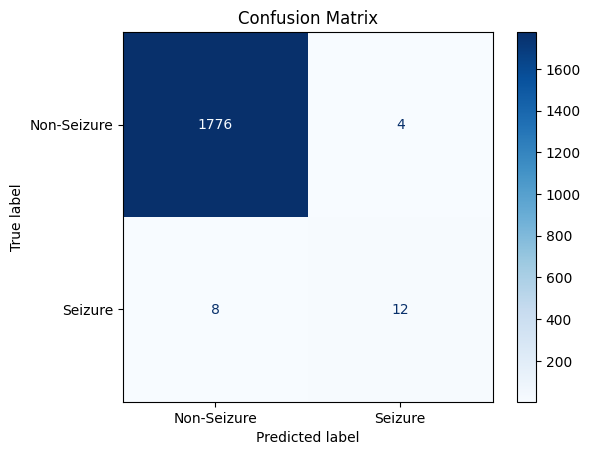

In [256]:
X = extract_l2_features(segments, 128)  # example
acc, cm = svm_evaluation(X, labels)

In [262]:
def svm_crossval_scores(X, y, n_splits=5):
    
    clf = SVC(kernel='rbf', class_weight='balanced')
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    scores = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')
    
    return scores

In [265]:
undersampling = {
    2: 256,
    4: 128,
    8: 64,
    16: 32,
    32: 16
}

results = {}

for uf, m in undersampling.items():
    X = extract_l2_features(segments, m)
    scores = svm_crossval_scores(X, labels)
    results[uf] = scores
    print(f"UF {uf} → Mean Accuracy: {np.mean(scores)*100:.2f}%")


UF 2 → Mean Accuracy: 99.44%
UF 4 → Mean Accuracy: 99.50%
UF 8 → Mean Accuracy: 99.17%
UF 16 → Mean Accuracy: 99.39%
UF 32 → Mean Accuracy: 99.06%


## Applying Boxplots

C:\Users\Admin\AppData\Local\Temp\ipykernel_15244\791743857.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results.values(), labels=results.keys())


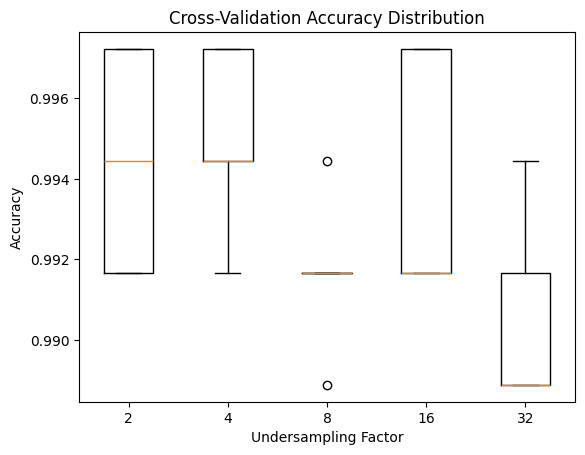

In [272]:
plt.figure()
plt.boxplot(results.values(), labels=results.keys())
plt.xlabel("Undersampling Factor")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Accuracy Distribution")
plt.show()

## Applying Scatterplots

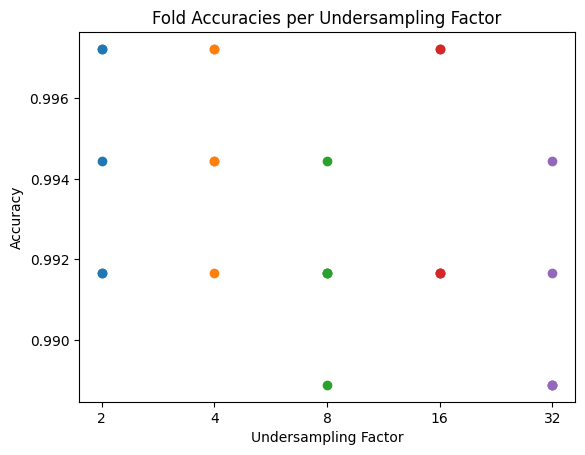

In [275]:
plt.figure()

for i, (uf, scores) in enumerate(results.items()):
    x = np.ones(len(scores)) * i
    plt.scatter(x, scores)

plt.xticks(range(len(results)), results.keys())
plt.xlabel("Undersampling Factor")
plt.ylabel("Accuracy")
plt.title("Fold Accuracies per Undersampling Factor")
plt.show()

## ===================== NEXT ==================================

## Cross-Validation Returning Sensitivity & Balanced Accuracy

In [333]:
def svm_crossval_metrics(X, y, n_splits=5):
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    sensitivities = []
    balanced_accuracies = []
    
    for train_idx, test_idx in skf.split(X, y):
        
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        clf = SVC(kernel='rbf', C=10, gamma='scale',
                  class_weight='balanced')
        
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        
        # Sensitivity = Recall of seizure class (label=1)
        sens = recall_score(y_test, y_pred, pos_label=1)
        sensitivities.append(sens)
        
        # Balanced Accuracy
        bal_acc = balanced_accuracy_score(y_test, y_pred)
        balanced_accuracies.append(bal_acc)
    
    return np.array(sensitivities), np.array(balanced_accuracies)

## Collection of Metrics for All Undersampling Factors

In [336]:
import matplotlib.pyplot as plt

undersampling = {
    2: 256,
    4: 128,
    8: 64,
    16: 32,
    32: 16
}

sens_results = {}
balacc_results = {}

for uf, m in undersampling.items():
    
    X = extract_l2_features(segments, m)
    sens, bal_acc = svm_crossval_metrics(X, labels)
    
    sens_results[uf] = sens
    balacc_results[uf] = bal_acc
    
    print(f"UF {uf}")
    print("Sensitivity:", sens)
    print("Balanced Accuracy:", bal_acc)
    print()

UF 2
Sensitivity: [0.25 0.25 0.5  1.   0.75]
Balanced Accuracy: [0.625      0.625      0.75       0.99859551 0.87359551]

UF 4
Sensitivity: [0.25 0.25 0.5  0.5  0.5 ]
Balanced Accuracy: [0.62359551 0.625      0.74859551 0.75       0.74859551]

UF 8
Sensitivity: [0.25 0.   0.5  0.5  1.  ]
Balanced Accuracy: [0.625      0.5        0.75       0.74859551 0.99859551]

UF 16
Sensitivity: [0.   0.   0.25 0.5  0.5 ]
Balanced Accuracy: [0.5        0.5        0.625      0.75       0.74859551]

UF 32
Sensitivity: [0.25 0.   0.   0.   0.5 ]
Balanced Accuracy: [0.62359551 0.49859551 0.5        0.5        0.74859551]



## Boxplot of Sensitivity

C:\Users\Admin\AppData\Local\Temp\ipykernel_15244\1960590378.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(sens_results.values(), labels=sens_results.keys())


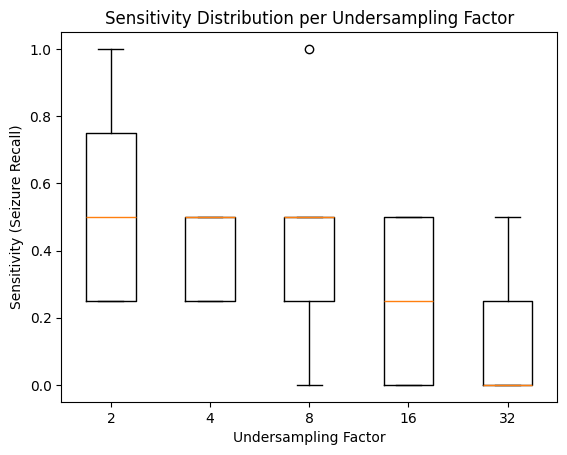

In [342]:
plt.figure()
plt.boxplot(sens_results.values(), labels=sens_results.keys())
plt.xlabel("Undersampling Factor")
plt.ylabel("Sensitivity (Seizure Recall)")
plt.title("Sensitivity Distribution per Undersampling Factor")
plt.show()

## Boxplot of Balanced Accuracy

C:\Users\Admin\AppData\Local\Temp\ipykernel_15244\726785212.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(balacc_results.values(), labels=balacc_results.keys())


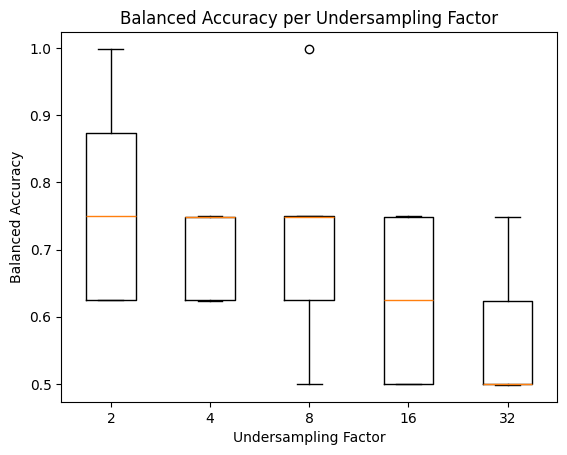

In [345]:
plt.figure()
plt.boxplot(balacc_results.values(), labels=balacc_results.keys())
plt.xlabel("Undersampling Factor")
plt.ylabel("Balanced Accuracy")
plt.title("Balanced Accuracy per Undersampling Factor")
plt.show()

## Paired t-test

Paired t-test p-values (Sensitivity):
UF 2 vs UF 4: p = 0.2080
UF 4 vs UF 8: p = 0.7040
UF 8 vs UF 16: p = 0.0993
UF 16 vs UF 32: p = 0.4766

Paired t-test p-values (Balanced Accuracy):
UF 2 vs UF 4: p = 0.2033
UF 4 vs UF 8: p = 0.7008
UF 8 vs UF 16: p = 0.1007
UF 16 vs UF 32: p = 0.4704


C:\Users\Admin\AppData\Local\Temp\ipykernel_15244\2635268830.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=ufs, patch_artist=True)


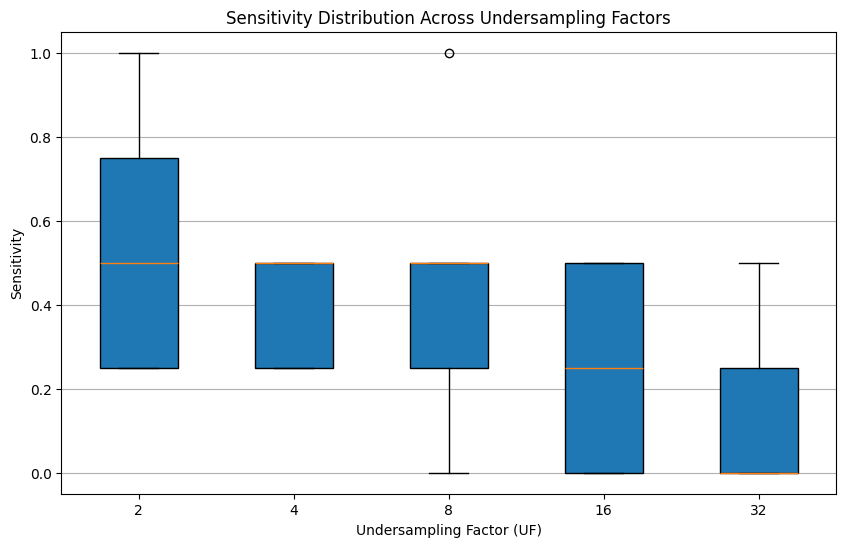

C:\Users\Admin\AppData\Local\Temp\ipykernel_15244\2635268830.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=ufs, patch_artist=True)


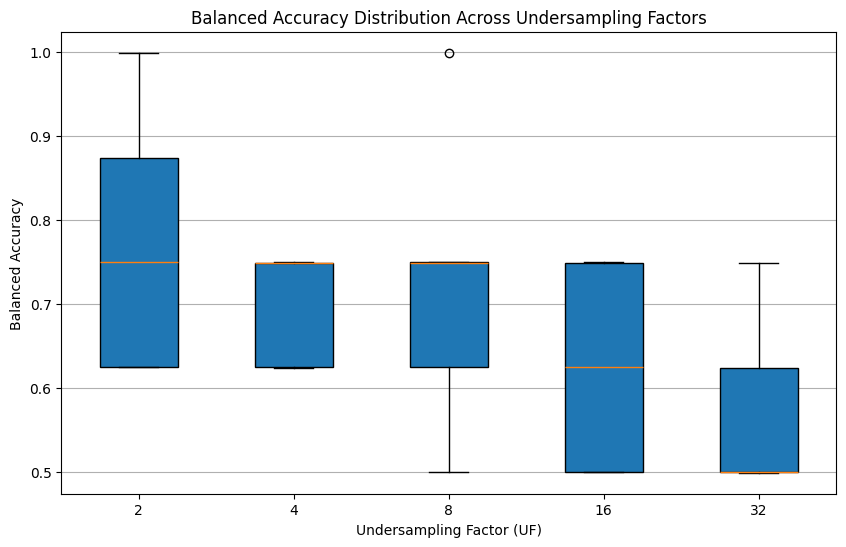

In [347]:
from scipy.stats import ttest_rel

# -------------------------------
# Your sensitivity and balanced accuracy per UF
# -------------------------------
results_sens = {
    2: np.array([0.25, 0.25, 0.5, 1.0, 0.75]),
    4: np.array([0.25, 0.25, 0.5, 0.5, 0.5]),
    8: np.array([0.25, 0.0, 0.5, 0.5, 1.0]),
    16: np.array([0.0, 0.0, 0.25, 0.5, 0.5]),
    32: np.array([0.25, 0.0, 0.0, 0.0, 0.5])
}

results_ba = {
    2: np.array([0.625, 0.625, 0.75, 0.99859551, 0.87359551]),
    4: np.array([0.62359551, 0.625, 0.74859551, 0.75, 0.74859551]),
    8: np.array([0.625, 0.5, 0.75, 0.74859551, 0.99859551]),
    16: np.array([0.5, 0.5, 0.625, 0.75, 0.74859551]),
    32: np.array([0.62359551, 0.49859551, 0.5, 0.5, 0.74859551])
}

ufs = sorted(results_sens.keys())

# -------------------------------
# Paired t-test for consecutive UFs
# -------------------------------
def paired_ttests(results_dict):
    ttest_results = {}
    for i in range(len(ufs)-1):
        uf1, uf2 = ufs[i], ufs[i+1]
        t_stat, p_val = ttest_rel(results_dict[uf1], results_dict[uf2])
        ttest_results[(uf1, uf2)] = p_val
    return ttest_results

pvals_sens = paired_ttests(results_sens)
pvals_ba = paired_ttests(results_ba)

print("Paired t-test p-values (Sensitivity):")
for k, v in pvals_sens.items():
    print(f"UF {k[0]} vs UF {k[1]}: p = {v:.4f}")

print("\nPaired t-test p-values (Balanced Accuracy):")
for k, v in pvals_ba.items():
    print(f"UF {k[0]} vs UF {k[1]}: p = {v:.4f}")

# -------------------------------
# Boxplot with significance annotation
# -------------------------------
def plot_boxplots(results_dict, metric_name):
    data = [results_dict[uf] for uf in ufs]
    
    plt.figure(figsize=(10,6))
    plt.boxplot(data, labels=ufs, patch_artist=True)
    plt.title(f'{metric_name} Distribution Across Undersampling Factors')
    plt.xlabel('Undersampling Factor (UF)')
    plt.ylabel(metric_name)
    plt.grid(axis='y')
    
    # Annotate significance for consecutive UFs
    for i in range(len(ufs)-1):
        p_val = paired_ttests(results_dict)[(ufs[i], ufs[i+1])]
        if p_val < 0.01:
            plt.text(i+1, max(max(data[i]), max(data[i+1]))+0.02, '**', ha='center', fontsize=16, color='red')
        elif p_val < 0.05:
            plt.text(i+1, max(max(data[i]), max(data[i+1]))+0.02, '*', ha='center', fontsize=16, color='red')
    
    plt.show()

# Plot Sensitivity
plot_boxplots(results_sens, 'Sensitivity')

# Plot Balanced Accuracy
plot_boxplots(results_ba, 'Balanced Accuracy')